In [1]:
import os
import sys
from pathlib import Path

PROJECT_ROOT = Path(os.path.abspath(".."))
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = Path(os.path.abspath("."))

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

DATA_DIR = PROJECT_ROOT / "data"
MODELS_DIR = PROJECT_ROOT / "models"
RESULTS_DIR = PROJECT_ROOT / "results"

In [2]:
RESEARCH_DATASET_DIR = (PROJECT_ROOT / "data" / "research_processed_smoke_auto").resolve()
RESEARCH_MODEL_DIR = (PROJECT_ROOT / "models" / "research_smoke_auto").resolve()
RESEARCH_RESULTS_DIR = (PROJECT_ROOT / "results" / "research_smoke_auto").resolve()

# 03 Evaluate

This notebook loads the trained model, runs sequential inference, computes anomaly scores and reconstruction errors, evaluates early detection, and saves outputs under `results/research_smoke_auto/`.

In [3]:
import matplotlib.pyplot as plt
import pandas as pd

from src.config import EvalConfig
from src.evaluate import evaluate_model
from src.utils import read_json

## Sequential Inference And Anomaly Score Calculation

In [4]:
cfg = EvalConfig(
    dataset_dir=RESEARCH_DATASET_DIR,
    model_dir=RESEARCH_MODEL_DIR,
    output_dir=RESEARCH_RESULTS_DIR,
    split="test",
    top_k_features=5,
    use_synthetic_injection=True,
    include_gpt_in_stream=True,
    telegram_enabled=True,
)
eval_summary = evaluate_model(cfg)
eval_summary["evaluation_summary"]

[evaluate] Starting evaluation: split=test, device=cuda, synthetic_injection=True, gpt_stream=True, telegram=True
[evaluate] Loaded split with 39160 windows and 8 features.
[evaluate] Scaling input features and context vectors.
[evaluate] Injecting synthetic anomalies into evaluation windows.
[evaluate] Running model reconstruction.


Reconstructing windows:   0%|                                                                                 …

[evaluate] Computing anomaly scores and threshold decisions.
[evaluate] Simulating realtime stream and optional GPT adjudication.


Streaming inference:   0%|                                                                                    …

[evaluate] Detected 302 anomalous windows at threshold 4.342865. Realtime alerts=302, GPT decisions=302.
[evaluate] Sending Telegram notifications for selected alerts.


Sending Telegram alerts:   0%|                                                                                …

[evaluate] Completed in 5483.8s. F1=0.0000, PR-AUC=0.0001, ROC-AUC=0.5406.


{'threshold': 4.342864990234375,
 'precision': 0.0,
 'recall': 0.0,
 'f1': 0.0,
 'pr_auc': 0.00013684095027533005,
 'roc_auc': 0.54056211053223,
 'num_windows': 39160,
 'num_positive_windows': 4,
 'num_realtime_alerts': 302,
 'num_gpt_decisions': 302,
 'split': 'test',
 'telegram_notifications_sent': 20,
 'telegram_notifications_failed': 0}

In [5]:
predictions = pd.read_csv(cfg.output_dir / "window_level_predictions.csv")
predictions.head()

,window_id,container_id,machine_id,end_time,split,anomaly_score,threshold,score_over_threshold,feature_error_vector,top_feature_rank,top_k_features,top_k_feature_errors,label,predicted_label,event_id
0,0,unknown_container,unknown_machine,0,test,0.065004,4.342865,-4.277861,"[0.06390167772769928, 0.0008200751035474241, 2...","[7, 0, 1, 5, 6, 4, 2, 3]","['disk_io', 'cpu_util', 'mem_util', 'net_in', ...","[0.4543784558773041, 0.06390167772769928, 0.00...",0,0,-1
1,1,unknown_container,unknown_machine,1,test,0.079327,4.342865,-4.263538,"[0.06148790568113327, 0.0018436014652252197, 2...","[7, 0, 1, 5, 6, 4, 2, 3]","['disk_io', 'cpu_util', 'mem_util', 'net_in', ...","[0.5706657767295837, 0.06148790568113327, 0.00...",0,0,-1
2,2,unknown_container,unknown_machine,2,test,0.064720,4.342865,-4.278145,"[0.04779358208179474, 0.0002388416905887425, 3...","[7, 0, 5, 6, 1, 4, 2, 3]","['disk_io', 'cpu_util', 'net_in', 'net_out', '...","[0.4671940803527832, 0.04779358208179474, 0.00...",0,0,-1
3,3,unknown_container,unknown_machine,3,test,0.055969,4.342865,-4.286896,"[0.023947453126311302, 0.0004335886624176055, ...","[7, 0, 1, 6, 5, 3, 4, 2]","['disk_io', 'cpu_util', 'mem_util', 'net_out',...","[0.42309486865997314, 0.023947453126311302, 0....",0,0,-1
4,4,unknown_container,unknown_machine,4,test,0.030176,4.342865,-4.312689,"[0.024093497544527054, 0.0016870311228558421, ...","[7, 0, 1, 6, 5, 3, 4, 2]","['disk_io', 'cpu_util', 'mem_util', 'net_out',...","[0.2149938941001892, 0.024093497544527054, 0.0...",0,0,-1


## Feature-Wise Reconstruction Error And Top-k Anomalous Features

In [6]:
predictions[
    [
        "window_id",
        "container_id",
        "anomaly_score",
        "top_k_features",
        "top_k_feature_errors",
    ]
].sort_values("anomaly_score", ascending=False).head(10)

,window_id,container_id,anomaly_score,top_k_features,top_k_feature_errors
38710,38710,unknown_container,25.175177,"['mem_gps', 'mpki', 'cpi', 'cpu_util', 'disk_io']","[184.3610076904297, 15.775625228881836, 0.5050..."
37870,37870,unknown_container,24.337849,"['mem_gps', 'mpki', 'cpu_util', 'cpi', 'disk_io']","[178.74974060058594, 14.660842895507812, 0.487..."
37281,37281,unknown_container,19.987984,"['mem_gps', 'mpki', 'cpi', 'cpu_util', 'disk_io']","[146.68467712402344, 11.848570823669434, 0.515..."
20421,20421,unknown_container,19.766123,"['mem_gps', 'mpki', 'cpu_util', 'cpi', 'disk_io']","[141.58143615722656, 12.591591835021973, 1.848..."
18607,18607,unknown_container,19.374149,"['mem_gps', 'mpki', 'cpu_util', 'cpi', 'disk_io']","[134.17005920410156, 17.3421573638916, 1.91487..."
19214,19214,unknown_container,19.323174,"['mem_gps', 'mpki', 'cpu_util', 'cpi', 'disk_io']","[133.9476776123047, 17.128582000732422, 1.9045..."
20757,20757,unknown_container,16.551456,"['mem_gps', 'mpki', 'cpu_util', 'cpi', 'disk_io']","[117.28305053710938, 11.284499168395996, 2.038..."
17749,17749,unknown_container,15.164255,"['mem_gps', 'mpki', 'cpu_util', 'cpi', 'disk_io']","[103.71792602539062, 14.483440399169922, 1.724..."
10013,10013,unknown_container,13.768902,"['mem_gps', 'mpki', 'cpu_util', 'disk_io', 'ne...","[104.83012390136719, 2.835879325866699, 0.9821..."
3566,3566,unknown_container,13.565071,"['mem_gps', 'mpki', 'disk_io', 'cpi', 'cpu_util']","[103.41690063476562, 4.0703444480896, 0.913964..."


## Precision, Recall, F1, PR-AUC, And ROC-AUC

In [7]:
evaluation_summary = read_json(cfg.output_dir / "evaluation_summary.json")
evaluation_summary

{'threshold': 4.342864990234375,
 'precision': 0.0,
 'recall': 0.0,
 'f1': 0.0,
 'pr_auc': 0.00013684095027533005,
 'roc_auc': 0.54056211053223,
 'num_windows': 39160,
 'num_positive_windows': 4,
 'num_realtime_alerts': 302,
 'num_gpt_decisions': 302,
 'split': 'test',
 'telegram_notifications_sent': 20,
 'telegram_notifications_failed': 0}

## Strict And Relaxed Early Detection Evaluation

In [8]:
event_metrics = read_json(cfg.output_dir / "event_metrics.json")
event_metrics

{'num_events': 1,
 'strict_detection_rate': 0.0,
 'relaxed_detection_rate': 0.0,
 'mean_detection_delay': None}

## Streaming-Style Inference Flow

In [9]:
realtime_stream = pd.read_csv(cfg.output_dir / "realtime_stream_predictions.csv")
realtime_stream.head()

,window_id,container_id,machine_id,end_time,split,anomaly_score,threshold,score_over_threshold,feature_error_vector,top_feature_rank,...,predicted_label,event_id,realtime_step,alert_ready,gpt_triggered,gpt_label,gpt_severity,gpt_recommended_action,gpt_explanation,compact_anomaly_summary
0,0,unknown_container,unknown_machine,0,test,0.065004,4.342865,-4.277861,"[0.06390167772769928, 0.0008200751035474241, 2...","[7, 0, 1, 5, 6, 4, 2, 3]",...,0,-1,0,False,False,NaN,NaN,NaN,NaN,"{""window_id"": 0, ""container_id"": ""unknown_cont..."
1,1,unknown_container,unknown_machine,1,test,0.079327,4.342865,-4.263538,"[0.06148790568113327, 0.0018436014652252197, 2...","[7, 0, 1, 5, 6, 4, 2, 3]",...,0,-1,1,False,False,NaN,NaN,NaN,NaN,"{""window_id"": 1, ""container_id"": ""unknown_cont..."
2,2,unknown_container,unknown_machine,2,test,0.064720,4.342865,-4.278145,"[0.04779358208179474, 0.0002388416905887425, 3...","[7, 0, 5, 6, 1, 4, 2, 3]",...,0,-1,2,False,False,NaN,NaN,NaN,NaN,"{""window_id"": 2, ""container_id"": ""unknown_cont..."
3,3,unknown_container,unknown_machine,3,test,0.055969,4.342865,-4.286896,"[0.023947453126311302, 0.0004335886624176055, ...","[7, 0, 1, 6, 5, 3, 4, 2]",...,0,-1,3,False,False,NaN,NaN,NaN,NaN,"{""window_id"": 3, ""container_id"": ""unknown_cont..."
4,4,unknown_container,unknown_machine,4,test,0.030176,4.342865,-4.312689,"[0.024093497544527054, 0.0016870311228558421, ...","[7, 0, 1, 6, 5, 3, 4, 2]",...,0,-1,4,False,False,NaN,NaN,NaN,NaN,"{""window_id"": 4, ""container_id"": ""unknown_cont..."


## Visualizations

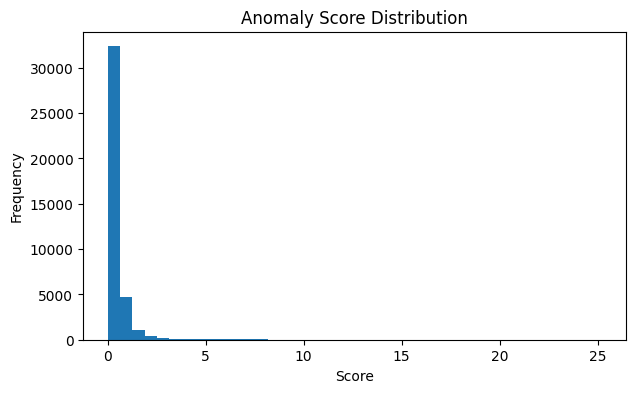

In [10]:
plt.figure(figsize=(7, 4))
predictions["anomaly_score"].plot(kind="hist", bins=40)
plt.title("Anomaly Score Distribution")
plt.xlabel("Score")
plt.show()

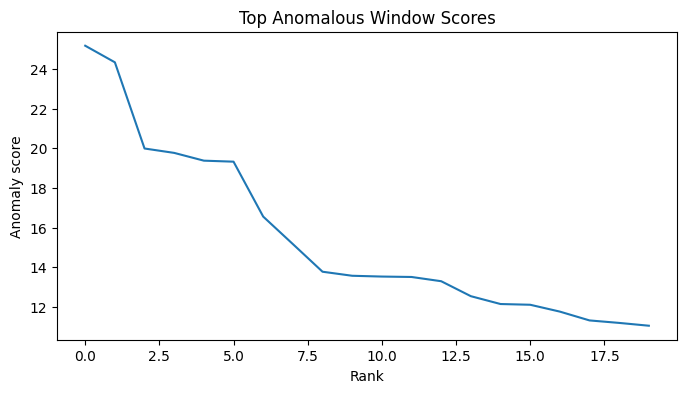

In [11]:
top_windows = pd.read_csv(cfg.output_dir / "top_anomalous_windows.csv")
plt.figure(figsize=(8, 4))
plt.plot(top_windows["anomaly_score"].head(20).to_numpy())
plt.title("Top Anomalous Window Scores")
plt.xlabel("Rank")
plt.ylabel("Anomaly score")
plt.show()